In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
df0 = pd.read_excel("data/xst.xlsx", sheet_name="A1.1")
df0.set_index("beta", inplace=True)
df1 = pd.read_excel("data/xst.xlsx", sheet_name="A2")
df1.set_index("beta", inplace=True)
df = pd.merge(df0, df1, left_index=True, right_index=True, how="inner", suffixes=("_0", ""))
df["trans"] = df["R"] / df["R_0"]
df["abs"] = 1 - df["trans"]
df

,R_0,R,trans,abs
beta,,,,
4.0,333,144,0.432432,0.567568
4.1,353,184,0.521246,0.478754
4.2,350,170,0.485714,0.514286
4.3,444,170,0.382883,0.617117
4.4,419,178,0.424821,0.575179
...,...,...,...,...
9.6,97,32,0.329897,0.670103
9.7,89,24,0.269663,0.730337
9.8,73,20,0.273973,0.726027


In [22]:
a_NACL = 564.02

beta_rad = np.radians(df.index)
df["lambda_pm"] = a_NACL * np.sin(beta_rad)

df.set_index("lambda_pm", inplace=True)

df.head()

,R_0,R,trans,abs
lambda_pm,,,,
39.344046,333,144,0.432432,0.567568
40.325989,353,184,0.521246,0.478754
41.307808,350,170,0.485714,0.514286
42.289502,444,170,0.382883,0.617117
43.271066,419,178,0.424821,0.575179


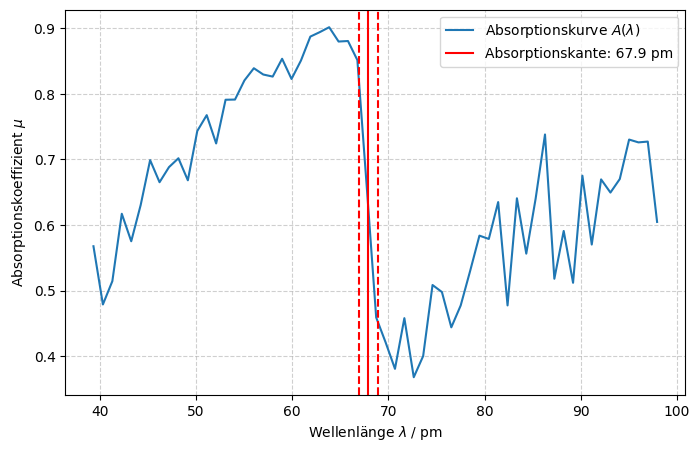

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df.index, df["abs"], linestyle='-', label='Absorptionskurve $A(\lambda)$')

ax.set_xlabel(r"Wellenlänge $\lambda$ / pm")
ax.set_ylabel(r"Absorptionskoeffizient $\mu$")

ax.grid(True, linestyle='--', alpha=0.6)


lambda_kante = 67.9   # Die Mitte der Kante (durchgezogene Linie)
breite = 1.0          # Bereich um die Kante (gestrichelte Linien)

ax.axvline(x=lambda_kante, color='red', linestyle='-', label=f'Absorptionskante: {lambda_kante} pm')
ax.axvline(x=lambda_kante - breite, color='red', linestyle='--')
ax.axvline(x=lambda_kante + breite, color='red', linestyle='--')

ax.legend()

plt.show()

In [34]:
from scipy.constants import h, c, e
from uncertainties import ufloat

l_pm = ufloat(67.9, 1.0)
l_m = l_pm * 1e-12

energy_ev = (h * c) / (l_m * e)
energy_kev = energy_ev / 1000

print(f"Energie: {energy_ev:.2f} eV")
print(f"Energie: {energy_kev:.2f} keV")

Energie: 18259.82+/-268.92 eV
Energie: 18.26+/-0.27 keV
